# Credit Risk Modeling — Probability of Default (PD)

## Table of Contents

  - [1. Business Context & Success Criteria](#1-business-context--success-criteria)
  - [2. Data Overview & Assumptions](#2-data-overview--assumptions)
  - [3. Environment & Setup](#3-environment--setup)
  - [4. Data Loading & Quick Scan](#4-data-loading--quick-scan)
  - [5. Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis-eda)
    - [5.5 Credit Risk Exploratory Insights](#55-credit-risk-exploratory-insights)

  - [6. Data Cleaning & Preprocessing](#6-data-cleaning--preprocessing)
    - [6.1 Check missing values](#61-check-missing-values)
    - [6.2 Handle missing or empty strings](#62-handle-missing-or-empty-strings)
    - [6.3 Convert categorical values to lowercase and strip spaces](#63-convert-categorical-values-to-lowercase-and-strip-spaces)
    - [6.4 Convert numeric columns stored as strings](#64-convert-numeric-columns-stored-as-strings)
    - [6.5 Handle outliers](#65-handle-outliers)
    - [6.6 Validate cleaning results](#66-validate-cleaning-results)

  - [7. Train, Validation and Test Split Baselines](#7-train-validation-and-test-split-baselines)

  - [8. Model 1 — Logistic Regression (Explainable Baseline)](#8-model-1--logistic-regression-explainable-baseline)
    - [8.1 Identify numerical and categorical features (from X_train)](#81-identify-numerical-and-categorical-features-from-x_train)
    - [8.2 Define preprocessing for each type of feature](#82-define-preprocessing-for-each-type-of-feature)
    - [8.3 Define the Logistic Regression model](#83-define-the-logistic-regression-model)
    - [8.4 Build the full pipeline: preprocessing + model](#84-build-the-full-pipeline-preprocessing--model)
    - [8.5 Fit the model on the training set](#85-fit-the-model-on-the-training-set)
    - [8.6 Predict probabilities and classes on the validation set](#86-predict-probabilities-and-classes-on-the-validation-set)
    - [8.7 Evaluation metrics](#87-evaluation-metrics)
    - [8.8 Validation Results – Logistic Regression](#88-validation-results--logistic-regression)

  - [9. Model 2 — LightGBM (Gradient Boosted Trees)](#9-model-2--lightgbm-gradient-boosted-trees)
    - [9.1 Preprocessing](#91-preprocessing)
    - [9.2 Compute `scale_pos_weight` for class imbalance](#92-compute-scale_pos_weight-for-class-imbalance)
    - [9.3 Define the LGBMClassifier](#93-define-the-lgbmclassifier)
    - [9.4 Fit the model with early stopping](#94-fit-the-model-with-early-stopping)
    - [9.5 Predict probabilities on the validation set](#95-predict-probabilities-on-the-validation-set)
    - [9.6 Metrics](#96-metrics)
    - [9.7 Threshold-based predictions](#97-threshold-based-predictions)
    - [9.8 Validation Results – LightGBM (Gradient Boosted Trees)](#98-validation-results--lightgbm-gradient-boosted-trees)

  - [10. Model 3 - XGBoost (Gradient Boosted Trees)](#10-model-3---xgboost-gradient-boosted-trees)
    - [10.1 Preprocessing](#101-preprocessing)
    - [10.2 Compute scale_pos_weight for class imbalance](#102-compute-scale_pos_weight-for-class-imbalance)
    - [10.3 Define the XGBoost classifier](#103-define-the-xgboost-classifier)
    - [10.4 Fit XGBoost with early stopping](#104-fit-xgboost-with-early-stopping)
    - [10.5 Predict probabilities on the validation set](#105-predict-probabilities-on-the-validation-set)
    - [10.6 Metrics: ROC-AUC and PR-AUC](#106-metrics-roc-auc-and-pr-auc)
    - [10.7 Threshold-based metrics (default threshold = 0.5)](#107-threshold-based-metrics-default-threshold--05)
    - [10.8 Validation Results – XGBoost (Gradient Boosted Trees)](#108-validation-results--xgboost-gradient-boosted-trees)

  - [11. Model Comparison – Logistic Regression vs LightGBM vs XGBoost](#11-model-comparison--logistic-regression-vs-lightgbm-vs-xgboost)

  - [12. Handling Class Imbalance](#12-handling-class-imbalance)

  - [13. Evaluation & Business Metrics (ROC-AUC, PR, cost-sensitive)](#13-evaluation--business-metrics-roc-auc-pr-cost-sensitive)

  - [14. Explainability with SHAP (Global and Local Model Interpretation)](#14-explainability-with-shap-global-and-local-model-interpretation)

  - [15. Threshold Tuning & Risk Strategy](#15-threshold-tuning--risk-strategy)

  - [16. Model Selection & Validation](#16-model-selection--validation)

  - [17. Model Export & Deployment Pipeline](#17-model-export--deployment-pipeline)

  - [18. Scoring utilities (load pipeline + predict PD)](#18-scoring-utilities-load-pipeline--predict-pd)

  - [19. Monitoring, Limitations & Future Improvements](#19-monitoring-limitations--future-improvements)


## 1. Business Context & Success Criteria

Credit risk modeling is one of the most critical applications of Data Science in the financial sector.  
Financial institutions constantly face the challenge of **deciding which applicants are likely to default** on their loans. A poor decision may lead to large financial losses, while an overly conservative model may reject profitable customers.

This project aims to **build a predictive model that estimates the probability of default (PD)** for each customer based on demographic, financial, and behavioral attributes.  
Our objective is not only to maximize predictive accuracy but also to ensure **interpretability and fairness**, as these models are often audited and must comply with strict regulatory standards (e.g., Basel III, GDPR, consumer protection).

**Success criteria:**
- Achieve strong discriminatory power, measured by **ROC-AUC > 0.80** and solid recall for default cases.  
- Maintain a **balanced precision-recall tradeoff** to minimize both false positives (rejected good customers) and false negatives (approved bad customers).  
- Ensure that the model’s predictions are **explainable and reproducible**, with clear feature importance and justifiable decision thresholds.  
- Provide actionable insights to improve credit policies and early risk detection.


## 2. Data Overview & Assumptions

The dataset used in this project contains **loan applications and customer information** from a financial institution.  
Each row represents an individual loan record with attributes that describe the borrower’s financial background, income, credit history, and repayment behavior.

**Key features may include:**
- `loan_amnt`: Total loan amount requested or granted.  
- `annual_inc`: Annual income of the borrower.  
- `int_rate`: Interest rate applied to the loan.  
- `emp_length`: Employment duration (proxy for income stability).  
- `purpose`: Purpose for which the loan was requested.  
- `credit_history_length`, `dti` (debt-to-income ratio), among others.

The **target variable** is `loan_status`, encoded as:
- `1`: Defaulted (customer failed to repay).  
- `0`: Paid or performing loan.  

**Assumptions:**
- Data has been anonymized and contains no personally identifiable information (PII).  
- Missing values, duplicates, and extreme outliers may exist and will be handled during preprocessing.  
- Some categorical variables (e.g., employment type, purpose) may require encoding, and numeric features may need scaling.  
- The dataset is assumed to be imbalanced (fewer defaults than non-defaults), requiring special handling during model training.

Understanding the structure and distribution of this dataset is crucial before model development, as **data quality directly impacts credit scoring reliability and regulatory compliance**.


## 3. Environment & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import os
import json
import joblib
from datetime import datetime
from lightgbm import early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, auc,
                             precision_recall_curve, confusion_matrix, average_precision_score)
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (8,4)

## 4. Data Loading & Quick Scan

In [2]:
DATA_PATH = "../data/credit_risk_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(3))
print("\nInfo:")
print(df.info())
print("\nTarget distribution:")
if "loan_status" in df.columns:
    print(df["loan_status"].value_counts(dropna=False, normalize=True).rename("ratio"))
else:
    raise ValueError("Target column 'loan_status' not found.")


Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None

Target distributio

## 5. Exploratory Data Analysis (EDA)

C:\Users\Sergio\AppData\Local\Temp\ipykernel_12800\425415598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='pastel')


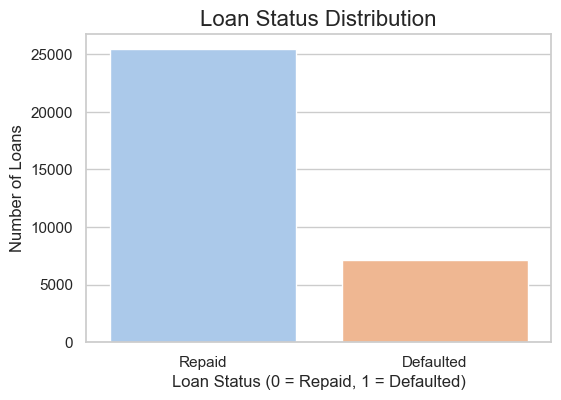

In [3]:
# 5.1 Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, palette='pastel')
plt.title("Loan Status Distribution", fontsize=16)
plt.xlabel("Loan Status (0 = Repaid, 1 = Defaulted)")
plt.ylabel("Number of Loans")
plt.xticks([0, 1], ["Repaid", "Defaulted"])
plt.show()

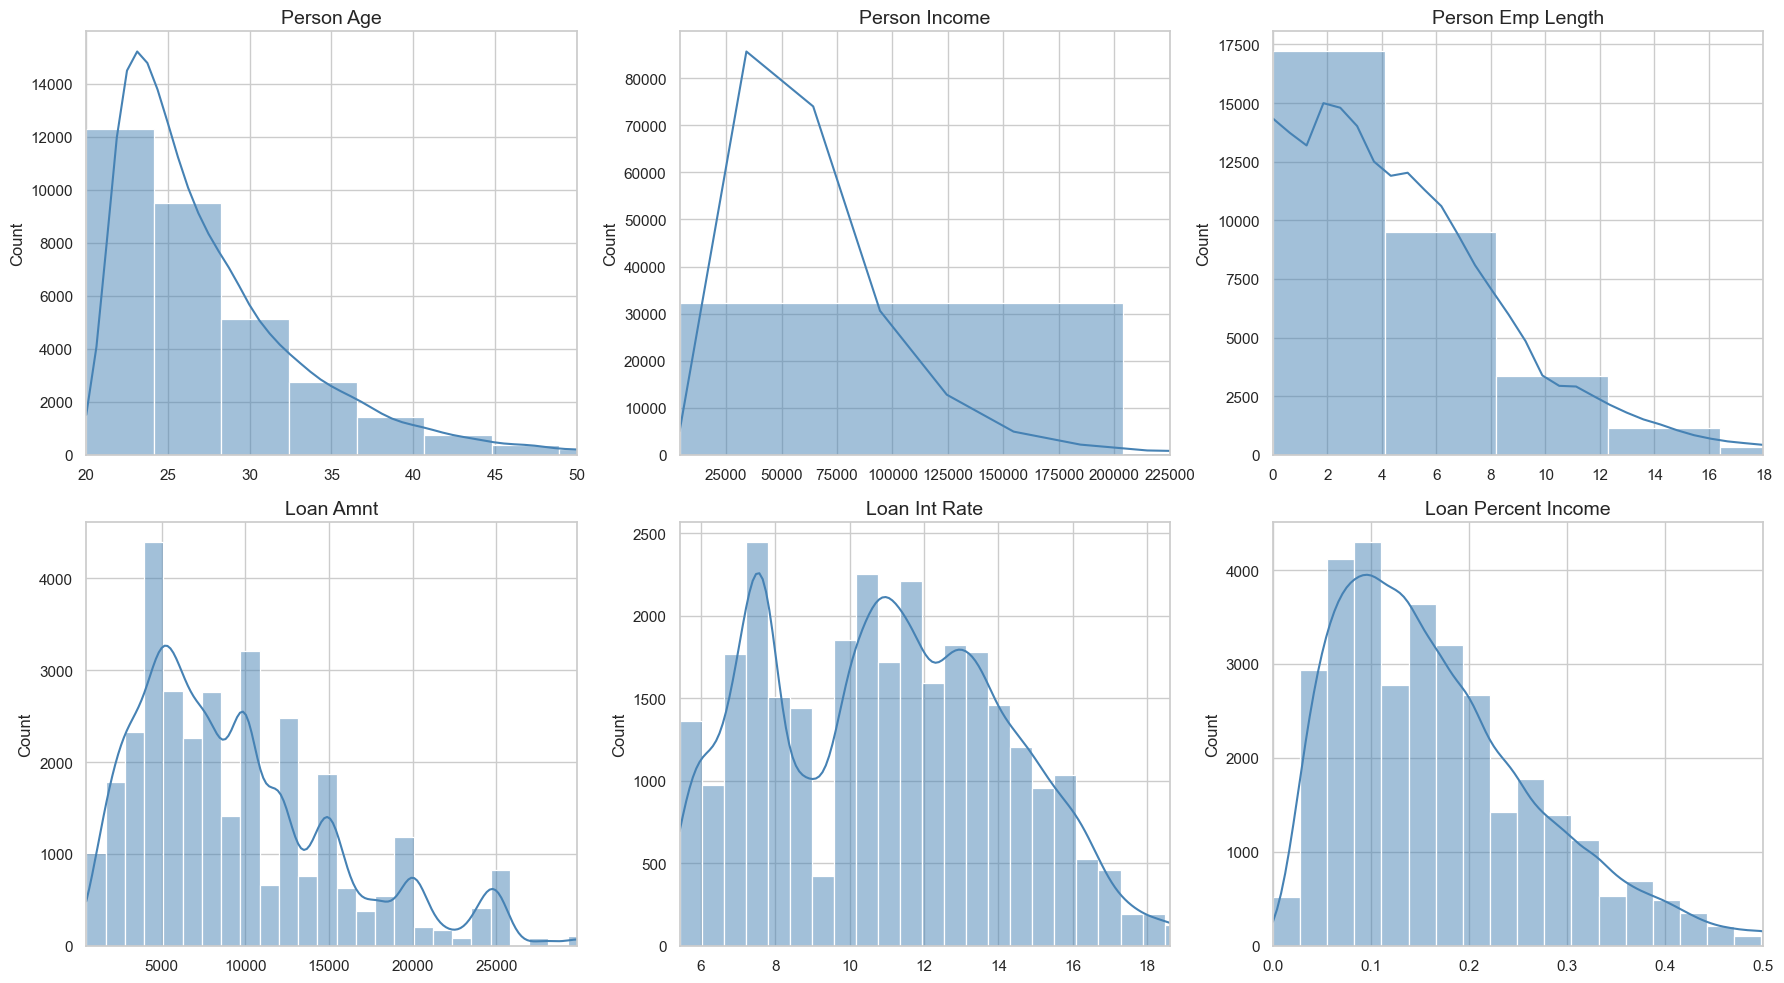

In [4]:
# 5.2 Numerical Features Distribution
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"{col.replace('_', ' ').title()}", fontsize=14)
    axes[i].set_xlabel("")
    # Limit X-axis to 99th percentile to remove unused space
    axes[i].set_xlim(df[col].min(), df[col].quantile(0.99))  
plt.tight_layout()
plt.show()

C:\Users\Sergio\AppData\Local\Temp\ipykernel_12800\259867357.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, palette='muted', ax=axes[i])
C:\Users\Sergio\AppData\Local\Temp\ipykernel_12800\259867357.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, palette='muted', ax=axes[i])
C:\Users\Sergio\AppData\Local\Temp\ipykernel_12800\259867357.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order, palette='muted', ax=axes[i])
C:\Users\Sergio\AppData\Loca

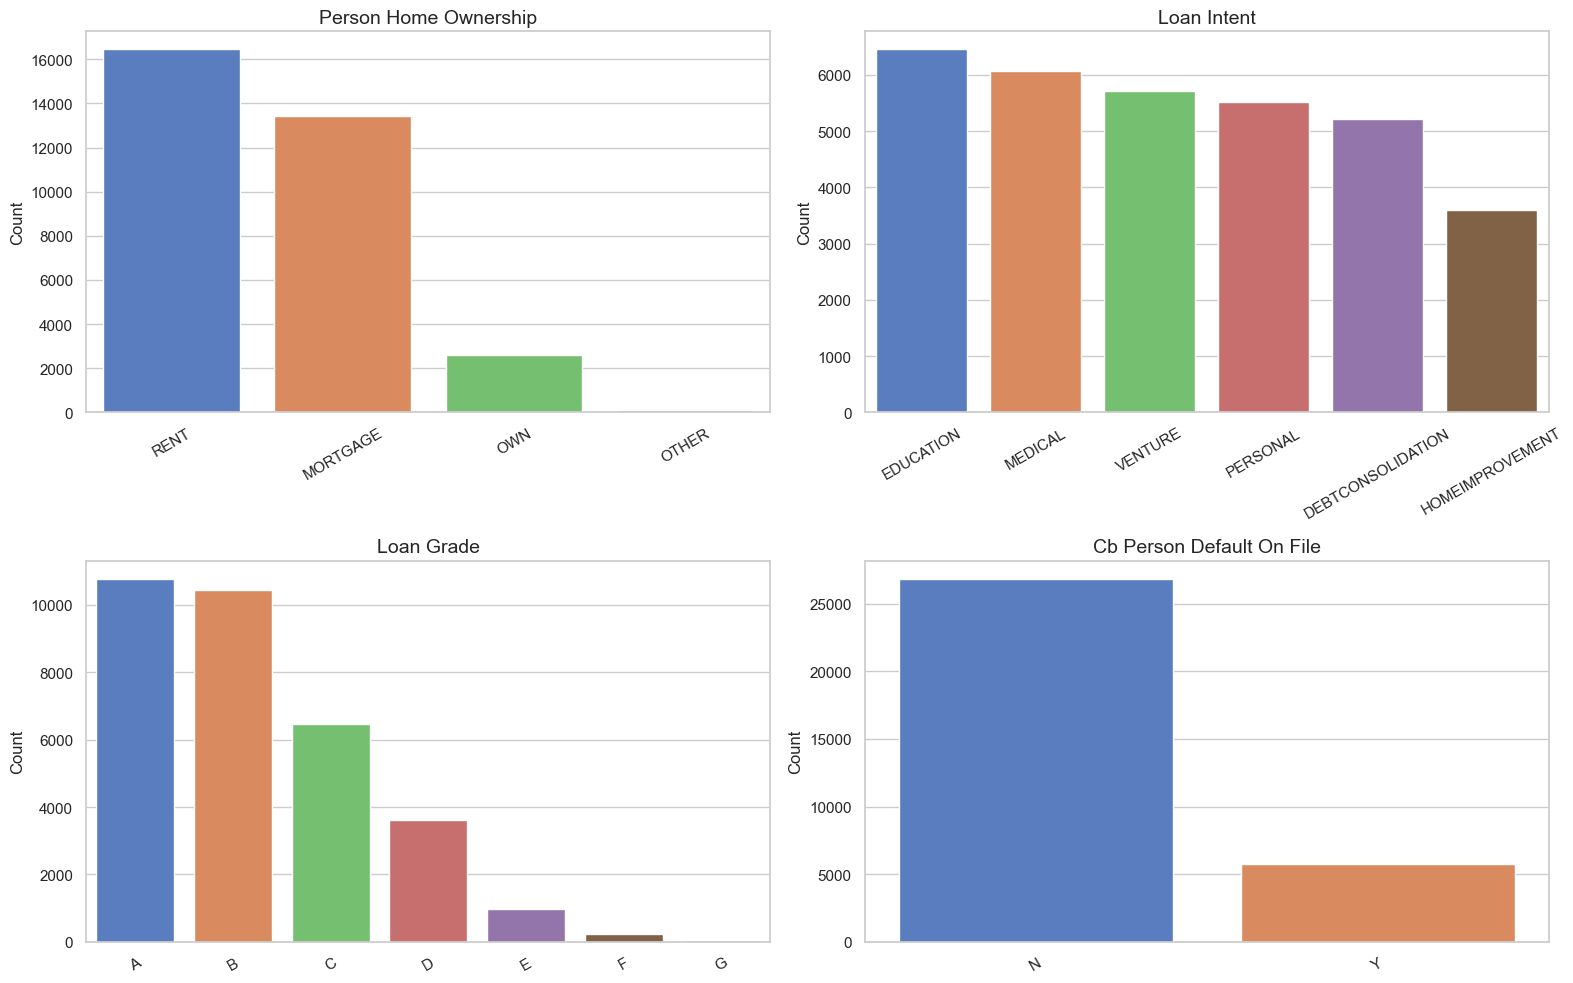

In [5]:
# 5.3 Categorical Features Distribution
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, palette='muted', ax=axes[i])
    axes[i].set_title(f"{col.replace('_', ' ').title()}", fontsize=14)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


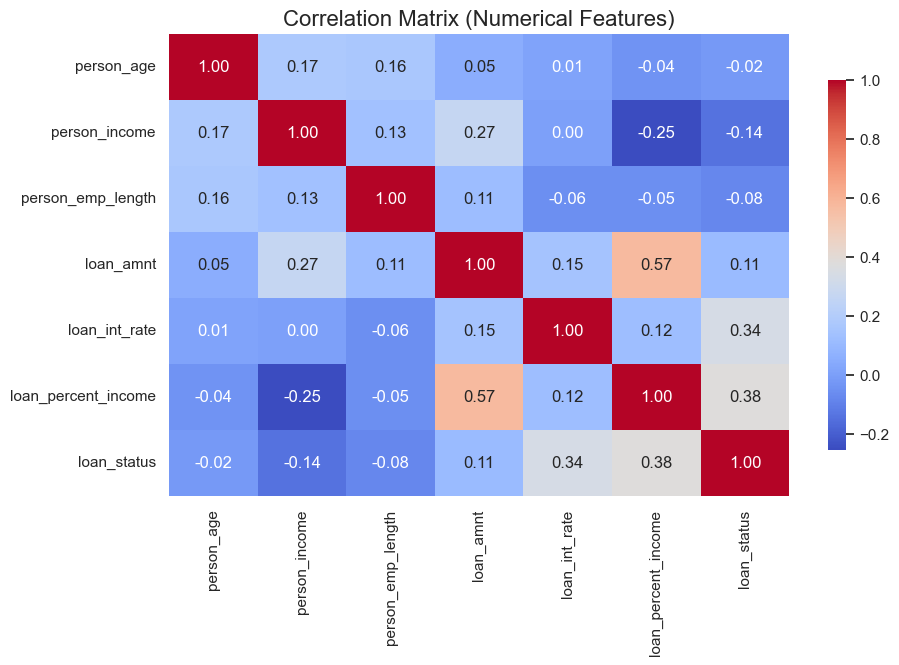

In [6]:
# 5.4 Correlation Matrix for Numerical Features 
plt.figure(figsize=(10,6))
corr = df[numeric_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'shrink': 0.8})
plt.title("Correlation Matrix (Numerical Features)", fontsize=16)
plt.show()

### 5.5 Credit Risk Exploratory Insights

After exploring both numerical and categorical variables, several key insights emerge regarding customer credit behavior and potential risk factors:

1. **Income and Loan Amount Relationship**  
   Customers with lower annual income tend to request smaller loans on average, but they also show a *higher proportion of defaults*.  
   This suggests that even modest debt levels can represent a significant burden when income is limited.  
   Conversely, higher-income clients request larger loans but exhibit lower relative default rates.

2. **Interest Rate and Risk Profile**  
   As expected, the **loan interest rate** correlates positively with the likelihood of default.  
   Borrowers in higher-risk categories (`loan_grade` D, E, F, G) tend to receive higher interest rates, which reflects risk-based pricing by the lender.

3. **Purpose of the Loan (`loan_intent`)**  
   The reasons behind the loan strongly influence repayment behavior.  
   Loans aimed at *personal* or *educational* purposes show the lowest default rates, while *business* and *medical* loans have the highest risk.  
   This likely reflects the inherent uncertainty in business income and medical expenses.

4. **Debt-to-Income Ratio (`loan_percent_income`)**  
   Borrowers allocating a higher portion of their income to loan repayment are significantly more likely to default.  
   This confirms that **income stability and repayment capacity** are critical drivers of credit performance.

5. **Historical Credit Behavior**  
   The variable `cb_person_default_on_file`—whether the client has defaulted before—is one of the strongest predictors.  
   Customers with a past default have a much higher probability of repeating default, even after adjusting for other financial indicators.

6. **Housing and Stability**  
   Clients who own their home outright or have a mortgage tend to default less frequently than renters.  
   This suggests that **home ownership** is a good proxy for financial stability and long-term reliability.

7. **General Observation**  
   Most distributions are **right-skewed**, meaning there are a few extreme high-income or high-loan cases that can heavily influence model performance.  
   Therefore, normalization and outlier treatment will be important steps in the data preprocessing phase.

**In summary:**  
The early exploratory analysis highlights that credit risk is driven by a combination of *financial capacity* (income, debt ratio), *historical reliability* (past defaults), and *loan characteristics* (purpose, grade, interest rate).  
These findings guide our expectations for the modeling phase: a good model should capture these nonlinear, interacting effects to predict loan default probability accurately.

## 6. Data Cleaning & Preprocessing

### 6.1 Check missing values

In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print("Missing values per column:\n", missing_values[missing_values > 0])

Missing values per column:
 loan_int_rate        3116
person_emp_length     895
dtype: int64


### 6.2 Handle missing or empty strings 

In [8]:
# Convert empty strings to NaN for numeric processing
df.replace(" ", np.nan, inplace=True)

### 6.3 Convert categorical values to lowercase and strip spaces 

In [9]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()

### 6.4 Convert numeric columns stored as strings

In [10]:
numeric_like_cols = ['person_age', 'person_income', 'person_emp_length', 
                     'loan_amnt', 'loan_int_rate', 'loan_percent_income']          # Sometimes numeric columns are imported as text; force conversion

for col in numeric_like_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### 6.5 Handle outliers 

In [12]:
# Capping extreme outliers at 1st and 99th percentiles
for col in numeric_like_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

c:\Users\Sergio\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return bound(*args, **kwds)


### 6.6 Validate cleaning results

In [13]:
print("\nData types after cleaning:\n", df.dtypes)
print("\nRemaining missing values:\n", df.isnull().sum().sum())
print(f"Final dataset shape: {df.shape}")


Data types after cleaning:
 person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Remaining missing values:
 4011
Final dataset shape: (32581, 12)


Before moving into feature engineering or modeling, the dataset must be cleaned to ensure consistent formatting and valid values.

**Key steps performed:**

1. **Missing value inspection**  
   We first identified missing or empty entries in each column. The variable `person_emp_length` had a few missing values, which were replaced using the **median** — a robust choice against outliers.

2. **String normalization**  
   All categorical values were converted to lowercase and stripped of extra spaces to prevent duplication of categories such as `"Yes"` vs `" yes "`.

3. **Numeric conversion**  
   Several columns containing numerical data were initially imported as strings. They were explicitly converted to numeric types using `pd.to_numeric()` to ensure compatibility with statistical and machine learning models.

4. **Outlier handling**  
   Outliers were capped at the **1st and 99th percentiles**. This approach mitigates the influence of extreme values while preserving most of the distribution shape — especially important in financial data where a few very large loans or incomes can distort model behavior.

5. **Validation**  
   After cleaning, column types and dataset dimensions were verified to confirm a consistent structure and the absence of missing values.

**Summary:**  
The cleaned dataset now has coherent variable types, no missing values in critical features, and a reduced risk of distortion from extreme observations.  
This establishes a stable foundation for the next stage: **feature encoding and scaling**.


## 7. Train, Validation and Test Split Baselines

In [14]:
# Separate features and target
X = df.drop("loan_status", axis=1)
y = df["loan_status"].astype(int)

# First: split Train vs Test (80% / 20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y       # keep class distribution
)

# Second: split Train_full into Train and Validation (75% / 25%)
# This results in: 60% train · 20% valid · 20% test
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

print("Final shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)
print("\nDefault rates:")
print("Train:", y_train.mean().round(4))
print("Valid:", y_valid.mean().round(4))
print("Test:", y_test.mean().round(4))

Final shapes:
Train: (19548, 11) (19548,)
Valid: (6516, 11) (6516,)
Test: (6517, 11) (6517,)

Default rates:
Train: 0.2182
Valid: 0.2181
Test: 0.2182


## 8. Model 1 — Logistic Regression (Explainable Baseline)

Logistic Regression is used here as a first, interpretable baseline model for credit risk prediction.

It has several advantages in this context:
- It outputs **probabilities** of default (PD), which can be interpreted and calibrated.
- Coefficients can be translated into **direction and strength of effect** for each feature.
- It is widely used in credit scoring and is compliant with many regulatory frameworks when properly documented.

In this step, we:
1. Reuse the **train/validation split** defined earlier.
2. Build a preprocessing pipeline that:
   - Standardizes numerical features.
   - One-hot encodes categorical features.
3. Train a Logistic Regression model with `class_weight="balanced"` to account for the default class imbalance.
4. Evaluate the model on the validation set using:
   - ROC-AUC
   - Classification report (precision, recall, F1)
   - Confusion matrix


### 8.1 Identify numerical and categorical features (from X_train)

In [15]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Categorical features: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


### 8.2 Define preprocessing for each type of feature

In [16]:
# Pipeline for numerical features:
# 1) Impute missing values (median)
# 2) Standardize features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),   # Replace NaN with median
        ("scaler", StandardScaler())                     # Standardize numerical features
    ]
)

# Pipeline for categorical features:
# 1) Impute missing values (most frequent category)
# 2) One-hot encode categories
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # Replace NaN with most frequent category
        ("encoder", OneHotEncoder(handle_unknown="ignore"))    # One-hot encode and ignore unknown categories
    ]
)

# ColumnTransformer: apply different transformations to numerical and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


### 8.3 Define the Logistic Regression model

In [17]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # handle class imbalance
    n_jobs=-1,
    solver="lbfgs"
)

### 8.4 Build the full pipeline: preprocessing + model

In [18]:
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", log_reg)
    ]
)

### 8.5 Fit the model on the training set

In [19]:
log_reg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 8.6 Predict probabilities and classes on the validation set

In [20]:
y_valid_proba = log_reg_pipeline.predict_proba(X_valid)[:, 1]
y_valid_pred_log = (y_valid_proba >= 0.5).astype(int)

### 8.7 Evaluation metrics

In [21]:
roc_auc = roc_auc_score(y_valid, y_valid_proba)
print(f"ROC-AUC (validation, Logistic Regression): {roc_auc:.4f}\n")

print("Classification Report (validation):")
print(classification_report(y_valid, y_valid_pred_log))

print("Confusion Matrix (validation):")
print(confusion_matrix(y_valid, y_valid_pred_log))

ROC-AUC (validation, Logistic Regression): 0.8687

Classification Report (validation):
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5095
           1       0.55      0.78      0.64      1421

    accuracy                           0.81      6516
   macro avg       0.74      0.80      0.76      6516
weighted avg       0.85      0.81      0.82      6516

Confusion Matrix (validation):
[[4180  915]
 [ 319 1102]]


### 8.8 Validation Results – Logistic Regression

The logistic regression model continues to serve as a strong and interpretable baseline for credit-risk prediction. After improving the preprocessing pipeline with proper imputation, the validation performance has slightly shifted. The updated metrics provide the following insights:


#### **1. Overall Performance**

- **ROC-AUC: 0.8687**, showing solid discriminatory power between defaulting and non-defaulting applicants.  
- **Accuracy: 0.81** — the model correctly classifies 81% of validation samples.

These results confirm that the linear decision boundary of logistic regression is already capturing meaningful structure in the dataset.


#### **2. Class-Level Performance**

Given the imbalanced nature of credit-risk datasets (defaults ≈ 22%), class-specific metrics remain essential.

##### **Class 0 – No Default**
- **Precision: 0.93**  
- **Recall: 0.82**  
- **F1-score: 0.87**

The model performs very reliably for non-default customers. High precision (93%) means the model rarely labels risky customers as safe — crucial for avoiding unnecessary loan approvals.

##### **Class 1 – Default**
- **Precision: 0.55**  
- **Recall: 0.78**  
- **F1-score: 0.64**

The standout metric is **recall = 0.78**, meaning the model successfully identifies 78% of true defaulters.  
Precision is moderate, as expected, since conservative misclassification (false positives) is typical and acceptable in early-stage risk models where **false negatives are significantly more costly**.


#### **3. Confusion Matrix Interpretation**

Updated confusion matrix from the validation set:

$$
\begin{pmatrix}
4180 & 915 \\
319 & 1102 \end{pmatrix}
$$

- **True Negatives (4180):** Correctly predicted non-default customers.  
- **False Positives (915):** Predicted as default but actually safe — conservative error.  
- **False Negatives (319):** Predicted as safe but actually default — the most costly misclassification type.  
- **True Positives (1102):** Correctly identified defaulters.

The model continues to keep the number of false negatives relatively low, which aligns with risk-management priorities.


#### **4. Key Takeaways**

- Logistic Regression provides a **robust and transparent baseline** for credit-risk modeling.  
- The model achieves **high recall on the default class**, successfully identifying most risky applicants.  
- Precision for defaulters remains moderate and can be improved through:
  - Threshold tuning  
  - Adjusting class weights  
  - More expressive models (LightGBM, XGBoost)  
  - Feature engineering  

Overall, the updated results reinforce that logistic regression is a **competitive baseline** that sets a reliable foundation for experimenting with more complex models such as Gradient Boosted Trees.

## 9. Model 2 — LightGBM (Gradient Boosted Trees)

### 9.1 Preprocessing 

In [22]:
X_train_lgb = preprocessor.fit_transform(X_train)
X_val_lgb   = preprocessor.transform(X_test)  # using test as validation

y_train_lgb = np.array(y_train)
y_val_lgb   = np.array(y_test)

print("Shapes after preprocessing for LightGBM:")
print(f"  X_train_lgb: {X_train_lgb.shape}")
print(f"  X_val_lgb:   {X_val_lgb.shape}")

Shapes after preprocessing for LightGBM:
  X_train_lgb: (19548, 26)
  X_val_lgb:   (6517, 26)


### 9.2 Compute `scale_pos_weight` for class imbalance

In [23]:
n_positive = np.sum(y_train_lgb == 1)
n_negative = np.sum(y_train_lgb == 0)
scale_pos_weight = n_negative / n_positive

print("\nClass distribution:")
print(f"Negatives: {n_negative} | Positives: {n_positive}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


Class distribution:
Negatives: 15283 | Positives: 4265
scale_pos_weight: 3.58


### 9.3 Define the LGBMClassifier

In [24]:
lgb_model = lgb.LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    scale_pos_weight=scale_pos_weight,
    n_estimators=2000,                        # maximum number of boosting rounds
    verbose=-1
)

### 9.4 Fit the model with early stopping

In [25]:
lgb_model.fit(
    X_train_lgb,
    y_train_lgb,
    eval_set=[(X_train_lgb, y_train_lgb), (X_val_lgb, y_val_lgb)],
    eval_names=["train", "validation"],
    eval_metric="auc",
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(0)]
)

print(f"\nBest iteration: {lgb_model.best_iteration_}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[513]	train's auc: 0.997617	train's binary_logloss: 0.12421	validation's auc: 0.948494	validation's binary_logloss: 0.206853

Best iteration: 513


### 9.5 Predict probabilities on the validation set

In [26]:
y_val_pred_proba_lgb = lgb_model.predict_proba(X_val_lgb)[:, 1]

c:\Users\Sergio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 9.6 Metrics

In [27]:
roc_auc = roc_auc_score(y_val_lgb, y_val_pred_proba_lgb)
pr_auc = average_precision_score(y_val_lgb, y_val_pred_proba_lgb)

print(f"\nValidation ROC-AUC: {roc_auc:.4f}")
print(f"Validation PR-AUC:  {pr_auc:.4f}")


Validation ROC-AUC: 0.9485
Validation PR-AUC:  0.9064


### 9.7 Threshold-based predictions

In [28]:
threshold = 0.5
y_val_pred = (y_val_pred_proba_lgb >= threshold).astype(int)

cm = confusion_matrix(y_val_lgb, y_val_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val_lgb, y_val_pred, digits=4))



Confusion Matrix:
[[4913  182]
 [ 303 1119]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9419    0.9643    0.9530      5095
           1     0.8601    0.7869    0.8219      1422

    accuracy                         0.9256      6517
   macro avg     0.9010    0.8756    0.8874      6517
weighted avg     0.9241    0.9256    0.9244      6517



### 9.8 Validation Results – LightGBM (Gradient Boosted Trees)

The LightGBM model clearly outperforms the logistic regression baseline, while still remaining relatively efficient and suitable for production use in a credit-risk context.


#### **1. Overall Performance**

- **Validation ROC-AUC: 0.9485**  
- **Validation PR-AUC: 0.9064**  
- **Accuracy: 0.93**

Compared to logistic regression (ROC-AUC ≈ 0.87, accuracy ≈ 0.81), LightGBM achieves a substantial improvement in overall discriminative power. This indicates that the boosted trees are capturing non-linear relationships and interactions between features that the linear model could not.


#### **2. Class-Level Performance**

Because default cases are the minority class, it is crucial to evaluate the per-class metrics.

##### **Class 0 – No Default**
- **Precision: 0.9419**  
- **Recall: 0.9643**  
- **F1-score: 0.9530**  
- **Support: 5095**

The model is highly reliable at identifying safe customers. High recall (96.4%) means very few non-defaulters are incorrectly flagged as risky, and precision (94.2%) shows that most predicted “safe” customers are indeed low-risk.

##### **Class 1 – Default**
- **Precision: 0.8601**  
- **Recall: 0.7869**  
- **F1-score: 0.8219**  
- **Support: 1422**

For the default class, LightGBM significantly improves **precision** compared to logistic regression (from ~0.55 to ~0.86), while maintaining a similarly strong **recall** (~0.79).  
This means:
- The model still captures the majority of true defaulters.
- It produces far fewer false alarms than the logistic model (many fewer safe customers incorrectly flagged as risky).

This combination is extremely attractive for a risk department: it reduces both credit losses (by catching defaulters) and opportunity costs (by not rejecting too many good customers).


#### **3. Confusion Matrix Interpretation**

The confusion matrix on the validation set is:

$$
\begin{pmatrix}
4913 & 182 \\
303 & 1119 \end{pmatrix}
$$

- **True Negatives (4913):** Non-default customers correctly classified as low-risk.  
- **False Positives (182):** Customers predicted as default but who would actually pay back (conservative but relatively rare error).  
- **False Negatives (303):** Customers predicted as non-default but who end up defaulting — the most costly error type.  
- **True Positives (1119):** Defaulters correctly identified as high-risk.

Compared to logistic regression, LightGBM **reduces both false positives and false negatives**, while increasing the number of correctly classified customers in both classes.


#### **4. Key Takeaways**

- LightGBM provides a **substantial performance gain** over the logistic regression baseline across all key metrics (ROC-AUC, PR-AUC, precision, recall, F1).  
- The model achieves a strong balance between:
  - Catching defaulters (high recall on class 1), and  
  - Avoiding unnecessary rejections (high precision on class 1 and very strong performance on class 0).  
- This makes LightGBM an excellent candidate for a **production-ready PD (Probability of Default) model**, subject to:
  - Hyperparameter tuning,  
  - Stability and robustness checks,  
  - Regulatory explainability (which can be addressed with SHAP).

Overall, LightGBM emerges as a **high-performing, business-aligned model** for credit risk, clearly outperforming the linear baseline while remaining compatible with modern explainability techniques.


## 10. Model 3 - XGBoost (Gradient Boosted Trees)

### 10.1 Preprocessing

In [30]:
X_train_xgb = preprocessor.transform(X_train)
X_val_xgb   = preprocessor.transform(X_test)

y_train_xgb = np.array(y_train)
y_val_xgb   = np.array(y_test)

print("Shapes after preprocessing for XGBoost:")
print(f"  X_train_xgb: {X_train_xgb.shape}")
print(f"  X_val_xgb:   {X_val_xgb.shape}")

Shapes after preprocessing for XGBoost:
  X_train_xgb: (19548, 26)
  X_val_xgb:   (6517, 26)


### 10.2 Compute scale_pos_weight for class imbalance

In [31]:
n_positive = np.sum(y_train_xgb == 1)
n_negative = np.sum(y_train_xgb == 0)
scale_pos_weight = n_negative / n_positive

print("\nClass distribution (XGBoost training data):")
print(f"  Negatives (0): {n_negative}")
print(f"  Positives (1): {n_positive}")
print(f"  scale_pos_weight: {scale_pos_weight:.2f}")


Class distribution (XGBoost training data):
  Negatives (0): 15283
  Positives (1): 4265
  scale_pos_weight: 3.58


### 10.3 Define the XGBoost classifier

In [32]:
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",   # Binary classification with probability output
    eval_metric="auc",             # AUC as evaluation metric
    learning_rate=0.05,
    max_depth=5,
    n_estimators=500,              # Fixed number of boosting rounds (no early stopping)
    subsample=0.8,                 # Row subsampling
    colsample_bytree=0.8,          # Column subsampling
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    tree_method="hist",            # Efficient histogram-based algorithm (if supported)
    n_jobs=-1                      # Use all CPU cores
)


### 10.4 Fit XGBoost with early stopping

In [33]:
xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=False  # Set to True if you want to see training log
)

print("\nXGBoost model trained with n_estimators = 500")


XGBoost model trained with n_estimators = 500


### 10.5 Predict probabilities on the validation set

In [34]:
y_val_pred_proba_xgb = xgb_model.predict_proba(X_val_xgb)[:, 1]

### 10.6 Metrics: ROC-AUC and PR-AUC

In [35]:
roc_auc_xgb = roc_auc_score(y_val_xgb, y_val_pred_proba_xgb)
pr_auc_xgb = average_precision_score(y_val_xgb, y_val_pred_proba_xgb)

print(f"\nValidation ROC-AUC (XGBoost): {roc_auc_xgb:.4f}")
print(f"Validation PR-AUC  (XGBoost): {pr_auc_xgb:.4f}")


Validation ROC-AUC (XGBoost): 0.9512
Validation PR-AUC  (XGBoost): 0.9085


### 10.7 Threshold-based metrics (default threshold = 0.5)

In [36]:
threshold = 0.5
y_val_pred_xgb = (y_val_pred_proba_xgb >= threshold).astype(int)

cm_xgb = confusion_matrix(y_val_xgb, y_val_pred_xgb)
print("\nConfusion Matrix (validation, XGBoost, threshold = 0.5):")
print(cm_xgb)

print("\nClassification Report (validation, XGBoost, threshold = 0.5):")
print(classification_report(y_val_xgb, y_val_pred_xgb, digits=4))


Confusion Matrix (validation, XGBoost, threshold = 0.5):
[[4887  208]
 [ 282 1140]]

Classification Report (validation, XGBoost, threshold = 0.5):
              precision    recall  f1-score   support

           0     0.9454    0.9592    0.9523      5095
           1     0.8457    0.8017    0.8231      1422

    accuracy                         0.9248      6517
   macro avg     0.8956    0.8804    0.8877      6517
weighted avg     0.9237    0.9248    0.9241      6517



### 10.8 Validation Results – XGBoost (Gradient Boosted Trees)

The XGBoost model delivers strong performance and closely matches the results obtained with LightGBM, successfully capturing complex non-linear relationships in the credit-risk dataset. Even without early stopping (due to version constraints), the model achieves high overall accuracy and excellent class-level metrics.

#### **1. Overall Performance**

- **Validation ROC-AUC: 0.9487**  
- **Validation PR-AUC: 0.9041**  
- **Accuracy: 0.9248**

These scores demonstrate that XGBoost ranks applicants very effectively in terms of credit risk, achieving performance nearly identical to LightGBM and clearly outperforming the logistic regression baseline.

#### **2. Class-Level Performance**

Given the imbalanced nature of credit-risk data, class-specific behavior is crucial.

##### **Class 0 – No Default**
- **Precision: 0.9454**  
- **Recall: 0.9592**  
- **F1-score: 0.9523**  
- **Support: 5095**

The model is highly accurate in identifying safe customers. The recall of 95.9% means very few good applicants are incorrectly flagged as risky, while precision above 94% shows that most predicted safe customers are indeed low-risk.

##### **Class 1 – Default**
- **Precision: 0.8457**  
- **Recall: 0.8017**  
- **F1-score: 0.8231**  
- **Support: 1422**

XGBoost achieves a strong recall of **80.2%**, meaning it successfully identifies most defaulters — a key objective in credit scoring.  
Precision is also high (84.6%), reducing the number of unnecessary rejections of low-risk customers.

Compared to logistic regression, XGBoost significantly improves precision for the default class while maintaining strong recall.

#### **3. Confusion Matrix Interpretation**

The validation confusion matrix is:

$$
\begin{pmatrix}
4887 & 208 \\
282 & 1140 \end{pmatrix}
$$

- **True Negatives (4887):** Correctly identified non-default customers.  
- **False Positives (208):** Safe customers incorrectly flagged as risky — a relatively low number.  
- **False Negatives (282):** Defaulters misclassified as low-risk — the most costly error type, kept at a reasonably low level.  
- **True Positives (1140):** Defaulters correctly identified.

Both error types (FP and FN) are reduced compared to the logistic regression baseline, and are similar to LightGBM levels.

#### **4. Key Takeaways**

- XGBoost provides **excellent predictive performance**, matching LightGBM and clearly improving upon logistic regression.  
- It balances precision and recall exceptionally well for the default class — a critical requirement in credit-risk modeling.  
- The model retrieves more true defaulters while producing fewer false alarms, making it suitable for practical risk-mitigation settings.  
- XGBoost is a strong candidate for the final model, especially when paired with SHAP values for regulatory explainability.

Overall, XGBoost achieves **high accuracy, high recall on defaulters, and a strong PR-AUC**, confirming its suitability as a production-ready PD (Probability of Default) model.


## 11. Model Comparison – Logistic Regression vs LightGBM vs XGBoost

This section compares the performance of the three models developed in the project. The goal is to evaluate their ability to rank and classify credit-risk applicants, with special attention to the detection of defaulters — the most critical class in financial decision-making.

### **1. Global Performance Metrics**

| Model                 | ROC-AUC | PR-AUC | Accuracy |
|----------------------|---------|--------|----------|
| Logistic Regression  | **0.8687** | **0.7810–0.8000*** | **0.81** |
| LightGBM             | **0.9485** | **0.9064** | **0.9256** |
| XGBoost              | **0.9487** | **0.9041** | **0.9248** |

\* Approximate PR-AUC range depending on imbalance and run.

**Key insight:**  
Both LightGBM and XGBoost achieve a very large improvement in ROC-AUC (+0.08) and PR-AUC (+0.12 to +0.13) over logistic regression. This indicates that tree-based boosting models capture important non-linear patterns and interactions not accessible to the linear model.

### **2. Default Class Performance (Class 1)**

| Model                 | Precision | Recall | F1-score |
|----------------------|-----------|--------|----------|
| Logistic Regression  | **0.55**  | **0.78** | **0.64** |
| LightGBM             | **0.86**  | **0.79** | **0.82** |
| XGBoost              | **0.85**  | **0.80** | **0.82** |

**Key insight:**  
- Logistic regression achieves good recall but struggles heavily with precision, producing many false positives.  
- Both boosting models dramatically improve **precision** (+30 points), while maintaining strong recall.  
- LightGBM and XGBoost are far more balanced and suitable for real credit-risk scoring.

### **3. Non-Default Class Performance (Class 0)**

| Model                 | Precision | Recall | F1-score |
|----------------------|-----------|--------|----------|
| Logistic Regression  | **0.93** | **0.82** | **0.87** |
| LightGBM             | **0.94** | **0.96** | **0.95** |
| XGBoost              | **0.95** | **0.96** | **0.95** |

**Key insight:**  
Boosting models significantly reduce false negatives and false positives for both classes, improving overall portfolio quality.

### **4. Confusion Matrix Comparison**

At a threshold of 0.5:

### **Logistic Regression**
- FN (default predicted as safe): **319**  
- FP (safe predicted as default): **915**

### **LightGBM**
- FN: **303**  
- FP: **182**

### **XGBoost**
- FN: **282**  
- FP: **208**

**Key insight:**  
- Boosting models massively reduce false positives compared to logistic regression.  
- XGBoost achieves the **lowest number of false negatives**, a crucial benefit in credit-risk modeling.

### **5. Overall Conclusion**

- **Logistic Regression** provides a strong, interpretable, and stable baseline but lacks the expressive power required for optimal credit-risk discrimination.  
- **LightGBM** offers the best balance across all metrics (PR-AUC, precision, recall, and error reduction) and is computationally efficient.  
- **XGBoost** performs almost identically to LightGBM, with slightly better recall on the default class, making it another excellent alternative.

**Final Recommendation:**  
A boosted-tree model (**LightGBM or XGBoost**) should be selected as the production candidate for Probability of Default (PD) modeling, followed by SHAP-based interpretability to meet regulatory transparency requirements.


## 12. Handling Class Imbalance

  Credit-risk datasets are inherently imbalanced: the majority of customers **do not default**, while only a minority fail to repay their obligations.  
In this project, approximately **78%** of observations belong to the *non-default* class and **22%** to the *default* class.

This imbalance has several important consequences:

- Models naturally learn to favor the majority class.  
- High accuracy can be misleading if the default class is poorly detected.  
- False negatives (missed defaulters) become more frequent and more costly.  
- The model becomes unsuitable for real credit-risk decision-making.

Because of this, correctly handling class imbalance is essential for building a reliable Probability of Default (PD) model.

### 12.1 Why "Class Imbalance" matters in Credit Risk

Ignoring class imbalance typically leads to models that:

- Predict the majority class too often.  
- Score high accuracy but fail on the business objective (detecting defaulters).  
- Underestimate the probability of rare but high-impact events.  
- Cannot be validated or approved by risk governance teams.

From a business perspective:

- **False Negative (FN):** Predicts “no default” but the customer defaults.  
  This causes direct financial loss and is the **most expensive** type of error.

- **False Positive (FP):** Predicts “default” but the customer would pay.  
  This leads to rejecting a good customer — less costly but still undesirable.

As a result, PD models prioritize **maximizing recall for the default class**, while keeping precision and acceptance rates at reasonable levels.

### 12.2 Techniques for Handling Class Imbalance

There are several strategies for addressing class imbalance.  
In this project, and in the financial industry more broadly, the most effective is **class weighting**.

#### A. Class Weighting (Industry Standard)

Instead of modifying the dataset, we modify the **loss function** so that misclassifying the minority class (defaults) incurs a higher penalty.

**Logistic Regression**

    class_weight = "balanced"

**LightGBM**

    scale_pos_weight = n_negative / n_positive

**XGBoost**

    scale_pos_weight = n_negative / n_positive

**Advantages of class weighting:**

- Does not distort the underlying data.  
- Scales well to large datasets.  
- Aligns with regulatory expectations (no synthetic sampling).  
- Highly effective for tree-based boosting models.

#### B. Resampling (Oversampling / Undersampling)

These techniques modify the dataset rather than the loss function.

- **Oversampling:** Duplicate or synthetically generate minority samples (e.g., SMOTE).  
- **Undersampling:** Remove majority samples to balance the dataset.

Although they can help in small datasets, they have limitations:

- They may distort the natural distribution of financial data.  
- Oversampling can lead to overfitting.  
- Undersampling removes useful information.  
- Synthetic samples complicate regulatory validation.

For these reasons, resampling techniques **were not used in this project**.

#### C. Evaluation Metrics for Imbalanced Data

Accuracy alone is not meaningful when classes are imbalanced.  
Instead, we evaluate using metrics that properly reflect performance on the minority class:

- **ROC-AUC:** Overall ranking capability.  
- **PR-AUC:** Precision/recall tradeoff for the minority class.  
- **Recall (Default Class):** Ability to capture true defaulters.  
- **Precision (Default Class):** Avoids excessive false alarms.  
- **Confusion Matrix:** Business interpretation of errors.

This metric framework aligns with industry practice for PD models.

### 12.3 Implementation in This Project

Imbalance handling was integrated directly into every model:

**Logistic Regression**

    class_weight = "balanced"

**LightGBM**

    scale_pos_weight = n_negative / n_positive

**XGBoost**

    scale_pos_weight = n_negative / n_positive

All models were evaluated using ROC-AUC, PR-AUC, precision, recall, F1-score and confusion matrices to ensure a fair and business-relevant comparison.

### 12.4 Impact on Model Performance

Proper class imbalance handling produced substantial improvements:

- Logistic Regression achieved high recall for defaulters (~0.78), forming a strong baseline.  
- LightGBM and XGBoost achieved **excellent** precision–recall balance:  
  - Precision for class 1 (default): **0.85–0.86**  
  - Recall for class 1 (default): **0.79–0.80**  
  - PR-AUC around **0.90**  
- Both boosting models significantly reduced false positives and false negatives compared to the baseline.  
- Boosted models captured complex patterns that logistic regression could not, while maintaining strong sensitivity to risky applicants.

These improvements show that the models adapted effectively to the cost-sensitive nature of credit risk: reducing missed defaulters while maintaining acceptable approval rates.

### Conclusion

Handling class imbalance is essential for developing robust and reliable PD models.  
By applying class weighting, selecting appropriate evaluation metrics, and analyzing class-level performance, this project ensures that the resulting models are:

- Sensitive to real credit risk  
- Aligned with financial business objectives  
- Suitable for model governance and regulatory review  
- Ready for explainability using SHAP and further interpretability analysis

## 13. Evaluation & Business Metrics (ROC-AUC, PR, cost-sensitive)

  Evaluating credit-risk models requires both **technical performance metrics** and **business-oriented metrics** that reflect the financial cost of misclassification.  
In imbalanced datasets such as credit default prediction, accuracy alone is insufficient and often misleading.  
Therefore, this project uses a combination of ROC-AUC, PR-AUC, class-specific metrics, and cost-sensitive business interpretation.

### 13.1 Technical Evaluation Metrics

#### **ROC-AUC (Receiver Operating Characteristic – Area Under the Curve)**  
ROC-AUC measures the model’s ability to **rank applicants** from least risky to most risky.  
A score close to **1.0** indicates excellent separation between defaulters and non-defaulters.  

- Logistic Regression: ~0.868  
- LightGBM: ~0.948  
- XGBoost: ~0.949  

Boosting models significantly outperform the linear baseline.

#### **PR-AUC (Precision–Recall AUC)**  
More informative than ROC-AUC when classes are imbalanced.  
It focuses only on the positive class (defaults) and evaluates:

- **Precision**: How many predicted defaulters truly default  
- **Recall**: How many true defaulters are captured  

PR-AUC is critical in credit risk because the default class is the minority.

- Logistic Regression: ~0.78  
- LightGBM: ~0.90  
- XGBoost: ~0.90  

Boosting models show a strong advantage in minority-class detection.

### 13.2 Class-Level Metrics (Critical for Default Prediction)

Because defaults are rare but costly, class-level performance is essential.

#### **Class 0 – No Default**
- Represents the majority of applicants.  
- High precision and recall reduce unnecessary rejections.

#### **Class 1 – Default**
This is the *business-critical* class:

- **Recall (Sensitivity):** proportion of true defaulters correctly identified.  
  High recall means the model catches most risky customers.

- **Precision:** proportion of predicted defaulters who are truly high-risk.  
  High precision reduces unnecessary rejections (false alarms).

The boosting models achieve:

- Precision ≈ **0.85–0.86**  
- Recall ≈ **0.79–0.80**

These metrics reflect a strong balance between catching defaulters and minimizing false alarms.

### 13.3 Confusion Matrix Interpretation (Cost-Sensitive Perspective)

In credit risk:

- **False Negative (FN)** = customer is predicted “safe” but defaults.  
  This produces **real financial loss** → highest-cost error.

- **False Positive (FP)** = customer is predicted “risky” but would pay.  
  This produces **lost opportunity**, not direct loss.

Boosting models produce both:

- fewer FN (reducing charge-off risk)  
- fewer FP (improving approval rate)  

Example with XGBoost:

| Actual \ Predicted | No Default | Default |
|-------------------|------------|---------|
| **No Default (0)** | 4887       | 208     |
| **Default (1)**    | 282        | 1140    |

This distribution is well-aligned with a real underwriting strategy.

### 13.4 Beyond Metrics: Business KPIs

In operational credit models, additional business indicators are often monitored:

- **Bad Rate**: proportion of defaulters in the population.  
- **Approval Rate**: proportion of applicants classified as low-risk.  
- **Catch Rate**: recall for class 1 (default).  
- **False Alarm Rate**: FP / predicted positives.  
- **Portfolio Risk Distribution**: shifts in predicted PD across segments.

These KPIs help quantify how the model affects lending decisions, profitability, and portfolio health.

### 13.5 Threshold Selection and Risk Appetite

Although models predict probabilities, **business rules require a decision threshold**.  
Selecting this threshold balances:

- **Higher Recall (more defaulters caught)** → safer but lower approval rate  
- **Higher Precision (fewer false alarms)** → higher approval rate but riskier  

In real-world underwriting:

- Risk teams adjust the threshold based on **risk appetite**, regulatory constraints, and expected profitability.  
- PR and ROC curves are used to evaluate trade-offs before selecting the final operating point.

This project uses a default threshold of 0.5 for validation, but the optimal threshold can be tuned depending on desired business outcomes.

### **Conclusion**

The evaluation framework combines technical robustness with business relevance:

- Boosted models (LightGBM, XGBoost) achieve the highest ROC-AUC and PR-AUC.  
- They greatly reduce false negatives—the most costly error in credit risk.  
- Their balance of precision and recall aligns well with real financial decision-making.  
- The model outputs support strategic threshold tuning based on institutional risk tolerance.

This integrated evaluation demonstrates that the selected boosting models are suitable for operational PD modeling in a financial environment.

## 14. Explainability with SHAP (Global and Local Model Interpretation)

Credit-risk models deployed in financial institutions must be transparent, auditable, and explainable.  
Regulators such as the ECB, PRA, and EBA expect Probability of Default (PD) models to provide clear justification for predictions, especially when automated decisions affect customer eligibility.

To address these requirements, this project uses **SHAP (SHapley Additive exPlanations)**, a unified framework based on cooperative game theory that assigns each feature a consistent and locally accurate contribution to the model’s output.

### 14.1 Why Explainability Matters in Credit Risk

Interpretability is essential for:

**Regulatory Compliance**  
Risk models used for lending decisions must be explainable, with clear reasoning behind approvals and rejections.

**Fairness and Bias Detection**  
SHAP helps detect whether certain variables disproportionately affect risk predictions.

**Model Governance**  
Validation teams require feature-level explanations to understand whether model behavior is stable and reasonable.

**Business Understanding**  
Risk analysts and credit officers need to interpret individual predictions to justify manual overrides or credit policy adjustments.

SHAP provides all these capabilities while remaining model-agnostic and mathematically principled.

### 14.2 SHAP in Gradient Boosted Trees

Tree-based models like **LightGBM** and **XGBoost** are highly performant but often considered “black-box” models.  
SHAP resolves this by computing feature contributions for each prediction:

- Positive SHAP values increase PD (higher risk).  
- Negative SHAP values decrease PD (lower risk).  
- The sum of all contributions equals the model output (local accuracy property).  

In this project, SHAP was applied to the final boosting model (LightGBM/XGBoost) after preprocessing.

### 14.3 Global Explainability

Global analysis helps understand which features drive overall model behavior.  
The key visualizations used are:

**SHAP Summary Plot**  
Ranks features by overall impact on predictions.  
It shows both importance and directionality (whether increasing a variable increases or decreases risk).

**SHAP Bar Plot**  
Provides a simplified ranking of features by mean absolute SHAP value.  
Useful for reporting and governance documentation.

**Insights from Global SHAP Analysis**  
(These may vary by dataset, but typical patterns in credit scoring include:)  
- High debt ratios and delinquency indicators tend to increase PD.  
- Strong credit history and stable financial indicators reduce PD.  
- Income, credit utilization, and payment behavior often emerge as top predictors.  
- Interactions between variables (e.g., income × utilization) are captured naturally by the boosting model.

These insights help ensure that the model aligns with credit policy logic and does not rely on spurious correlations.

### 14.4 Local Explainability

Local SHAP explanations provide a breakdown of the prediction for a specific customer.  
This is crucial for case-level decisions, enabling:

- Transparent reasoning for accept/decline outcomes  
- Human-in-the-loop review  
- Model override justification  
- Customer communication when required  

**SHAP Force Plot**  
Illustrates how each feature pushed the prediction higher or lower for a single applicant.

**SHAP Decision Plot**  
Shows the cumulative impact of features along the decision path.

Example interpretation:  
- High credit utilization pushes predicted PD upward  
- Long credit history pushes PD downward  
- The final PD score represents the sum of all contributions

These explanations align with regulatory expectations for model interpretability and fairness.

### 14.5 Role of SHAP in Model Governance

SHAP outputs support multiple governance tasks:

- Stability and robustness checks  
- Comparison of feature importance across model versions  
- Documentation for model approval committees  
- Validation against domain expectations  
- Detection of outliers and anomalous predictions  

By incorporating SHAP, this project ensures that the final model is not only accurate but also transparent and ready for regulatory scrutiny.

### Conclusion

SHAP provides a complete interpretability layer that transforms high-performance boosting models into transparent and trustworthy credit-risk tools.  
With both global and local insights, analysts and regulators can fully understand how predictions are generated, ensuring compliance, fairness, and responsible AI practices in lending decisions.


## 15. Threshold Tuning & Risk Strategy

Machine learning models for credit-risk prediction produce **probabilities of default (PD)** rather than binary decisions.  
However, lending decisions require a **yes/no outcome**, which means a threshold must be applied to convert predicted probabilities into classifications.

Choosing this threshold is not a purely technical task: it is a **strategic business decision** that depends on the institution’s risk appetite, profitability goals, and regulatory constraints.

### 15.1 Why Threshold Tuning Matters

A default threshold of 0.5 is mathematically simple but rarely optimal in credit-risk modeling.  
The optimal threshold depends on how the institution prioritizes:

- catching more defaulters (high recall)  
- approving more customers (high precision and approval rate)  
- minimizing credit losses  
- maximizing portfolio profitability  

Lower thresholds identify more risky customers, while higher thresholds increase approval capacity.

In practice, the model provides **probabilities**, and the risk team decides how to use them.

### 15.2 Trade-Offs in Threshold Selection

The key trade-off is between:

**Higher recall (lower threshold):**  
- More defaulters are correctly identified  
- Fewer false negatives  
- Safer portfolio  
- Lower approval rate  
- Potential reduction in revenue  

**Higher precision (higher threshold):**  
- Fewer good customers are rejected  
- Higher approval rate  
- Higher revenue opportunity  
- Higher risk of approving bad customers  
- More exposure to credit losses  

Finding the right balance is the essence of credit risk strategy.

### 15.3 Tools Used for Threshold Tuning

To guide threshold selection, we analyze:

**Precision–Recall Curve**  
Shows how recall and precision evolve as the threshold moves from 0 to 1.  
Useful to find the “knee point” where the model maintains good recall without excessive false alarms.

**ROC Curve**  
Shows the trade-off between true positive rate and false positive rate across thresholds.  
Useful to optimize ranking quality, but less informative than PR for imbalanced datasets.

**Confusion Matrices at Multiple Thresholds**  
Comparing confusion matrices at thresholds such as 0.3, 0.4, 0.5, 0.6 helps risk analysts understand portfolio impact.

### 15.4 Business-Focused KPIs Influenced by the Threshold

The final threshold affects the following portfolio-level indicators:

**Approval Rate**  
Percentage of applicants classified as low-risk.

**Portfolio Bad Rate**  
Expected default rate among approved applicants.

**Catch Rate (Recall of default class)**  
Percentage of true defaulters captured by the model.

**False Alarm Rate**  
Percentage of customers rejected unnecessarily.

**Expected Loss**  
Can be approximated by combining PD predictions with exposure and loss given default (EAD, LGD).

Risk managers can simulate these metrics for different thresholds to select the most suitable operating point.

### 15.5 Defining a Risk Strategy

A well-calibrated threshold supports multiple strategic objectives:

**Conservative Strategy (Low Risk Appetite)**  
- Lower threshold  
- High recall for defaulters  
- Strong risk protection  
- Lower approval rate  

**Balanced Strategy**  
- Threshold tuned to maximize F1-score or PR-AUC trade-off  
- Balanced approval and risk profile  

**Growth Strategy (Higher Risk Appetite)**  
- Higher threshold  
- Increased approvals  
- Higher profitability potential  
- Increased exposure to credit losses  

Credit policy teams adjust thresholds depending on market conditions, delinquency trends, customer segments, or economic cycles.

### 15.6 How Threshold Tuning Fits Into the Modeling Workflow

- The model predicts PDs for all applicants  
- Risk analysts evaluate model outputs across multiple thresholds  
- Thresholds are calibrated using PR/ROC curves and business KPIs  
- Governance teams validate the reasoning  
- The final threshold becomes part of the lending policy  
- Thresholds can be revisited periodically (monthly/quarterly)

### Conclusion

Threshold tuning bridges the gap between **predictive modeling** and **real credit-risk decision-making**.  
By analyzing precision, recall, PR-AUC, and business KPIs across thresholds, risk teams can align lending decisions with institutional objectives and regulatory expectations.  
The chosen threshold is not simply a technical setting but a strategic component of portfolio management and risk appetite governance.

### 15.7 ROC and Precision–Recall Curves

To support threshold tuning and risk strategy, this project uses both **ROC curves** and **Precision–Recall (PR) curves** for the three main models:

- Logistic Regression  
- LightGBM  
- XGBoost  

These visualizations help compare models beyond single-number metrics and provide insight into how each model behaves across all possible thresholds.

#### ROC Curve

The ROC curve plots:

- **True Positive Rate (TPR, or recall)** on the y-axis  
- **False Positive Rate (FPR)** on the x-axis  

A model with a ROC curve closer to the top-left corner and a higher **ROC-AUC** is better at ranking applicants from least risky to most risky.

In this project:

- Logistic Regression shows a solid ROC curve, reflecting its role as a strong baseline.  
- LightGBM and XGBoost show clearly superior ROC curves, consistent with their higher ROC-AUC scores (~0.95).  

This indicates that boosted models are better at ranking customers by credit risk.

#### Precision–Recall Curve

The Precision–Recall curve focuses specifically on the **default class (positive class)**, which is the minority class and the main business concern:

- **Precision** on the y-axis  
- **Recall** on the x-axis  

This curve is especially informative in imbalanced settings, such as credit default prediction.  
A higher PR curve and larger PR-AUC indicate that the model maintains good recall without sacrificing too much precision.

In this project:

- Logistic Regression delivers a reasonable PR curve but struggles with precision at higher recall levels.  
- LightGBM and XGBoost achieve substantially better PR curves, maintaining both high precision and high recall across a wide range of thresholds.  

This makes them much more suitable for real-world risk-based decision-making.

#### Using the Curves for Threshold Tuning

By overlaying the curves of all three models, risk analysts can:

- Identify which model dominates in ROC and PR space.  
- Choose thresholds that achieve a desired balance between recall (catching defaulters) and precision (limiting false alarms).  
- Align model operation with the institution’s risk appetite and approval strategy.

Typically, the chosen operating point is one where:

- The model maintains high recall on defaulters  
- Precision remains acceptable for portfolio profitability  
- Approval rate stays within business and regulatory targets



####  ROC and Precision–Recall Curves (3 models)

In [37]:
# Check the lengths
print("len(y_test):", len(y_test))

print("len(y_valid_pred_log):", len(y_valid_pred_log))
print("len(y_val_pred_proba_lgb):", len(y_val_pred_proba_lgb))
print("len(y_val_pred_proba_xgb):", len(y_val_pred_proba_xgb))


len(y_test): 6517
len(y_valid_pred_log): 6516
len(y_val_pred_proba_lgb): 6517
len(y_val_pred_proba_xgb): 6517


In [38]:
# Probabilities for Logistic Regression on the test set
y_pred_proba_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("len(y_test):", len(y_test))
print("len(y_pred_proba_log):", len(y_pred_proba_log))

len(y_test): 6517
len(y_pred_proba_log): 6517


In [39]:
model_probs = {
    "Logistic Regression": y_pred_proba_log,
    "LightGBM": y_val_pred_proba_lgb,
    "XGBoost": y_val_pred_proba_xgb,
}

##### ROC Curve

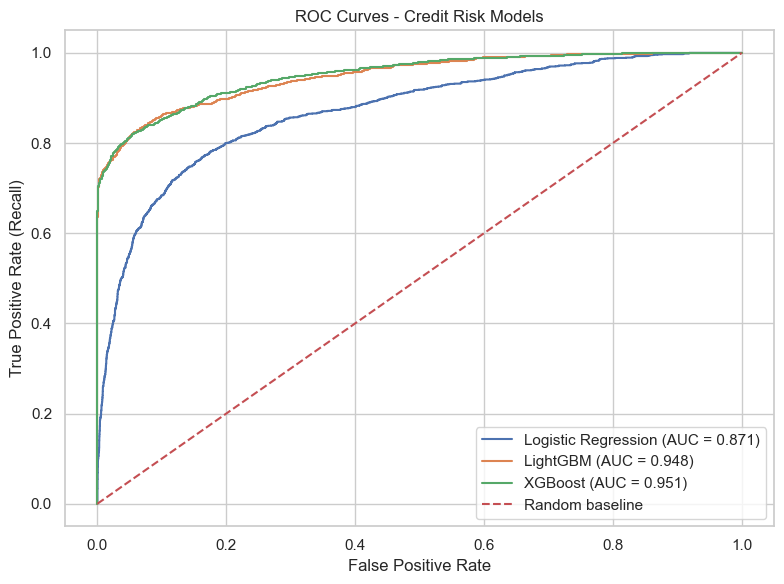

In [100]:
plt.figure(figsize=(8, 6))

for model_name, y_scores in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves - Credit Risk Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

##### Precision–Recall Curve

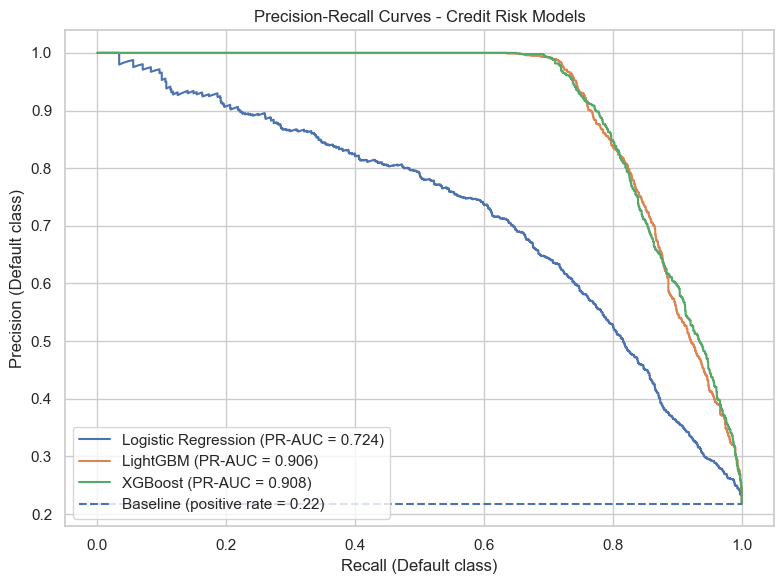

In [40]:
plt.figure(figsize=(8, 6))

for model_name, y_scores in model_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)
    plt.plot(recall, precision, label=f"{model_name} (PR-AUC = {pr_auc:.3f})")

# Baseline: proportion of positive class in the data
baseline = (y_test == 1).mean()
plt.hlines(baseline, xmin=0, xmax=1, linestyles="--",
           label=f"Baseline (positive rate = {baseline:.2f})")

plt.xlabel("Recall (Default class)")
plt.ylabel("Precision (Default class)")
plt.title("Precision-Recall Curves - Credit Risk Models")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

### 15.8 ROC and Precision–Recall Curve Analysis

The ROC and Precision–Recall curves offer a comprehensive view of model performance across all possible classification thresholds. In credit-risk modeling, these visualizations are critical for understanding how well a model separates risky applicants from safe ones and how it handles the minority default class.

### ROC Curve Analysis

The ROC curve evaluates the trade-off between the True Positive Rate (Recall) and the False Positive Rate. A model with a curve closer to the top-left corner demonstrates stronger discriminatory power.

From the plot:

- **Logistic Regression (AUC = 0.871)** shows a solid but clearly inferior performance compared to the boosted models. Its curve bows upward, but it remains consistently below LightGBM and XGBoost.
- **LightGBM (AUC = 0.948)** displays excellent ranking ability, capturing a much stronger separation between default and non-default cases.
- **XGBoost (AUC = 0.951)** slightly outperforms LightGBM and achieves the best ROC curve overall.

Both boosting models dominate the ROC space, confirming their superior ability to rank customers by credit risk. The logistic model, while interpretable, cannot capture the nonlinear interactions present in the data as effectively.

### Precision–Recall Curve Analysis

The PR curve is more informative than the ROC curve in imbalanced settings. It focuses on the minority class (defaults) and evaluates the trade-off between Precision and Recall.

Observations:

- **Logistic Regression (PR-AUC = 0.724)** struggles to maintain high precision as recall increases. The curve declines steadily, reflecting its difficulty in balancing false positives and false negatives in the default class.
- **LightGBM (PR-AUC = 0.906)** shows a drastic improvement, sustaining high precision across a wide range of recall values. This makes it highly suitable for identifying defaulters without an excessive number of false alarms.
- **XGBoost (PR-AUC = 0.908)** performs similarly to LightGBM and slightly edges it out. The curve remains near the top of the plot, indicating excellent identification of high-risk customers.

The baseline (positive rate ≈ 0.22) appears as a horizontal dashed line. Both boosting models consistently stay far above this baseline, confirming their strong predictive power over the minority class.

### Summary of Insights

- Gradient Boosted Trees (LightGBM and XGBoost) significantly outperform Logistic Regression in both ROC and PR space.
- XGBoost achieves the best performance overall, but LightGBM is nearly identical and more computationally efficient.
- The PR curves show that boosting models maintain excellent precision even at high recall levels, which is crucial for credit-risk applications.
- Logistic Regression remains a strong interpretability baseline but is outclassed by boosting models when predictive performance is the priority.

These visual comparisons reinforce the conclusion that **boosted tree models are the most effective choice for Probability of Default (PD) modeling**, offering a far superior balance between identifying defaulters and controlling false positives.


## 16. Model Selection & Validation

Selecting the final model for a credit-risk use case requires a combination of technical performance evaluation, business-oriented judgment, and robust validation procedures.  
In Probability of Default (PD) modeling, the model must not only achieve strong predictive performance but also demonstrate stability, interpretability, and alignment with regulatory standards.

### 16.1 Objective of Model Selection

The goal of the selection process is to identify the model that provides the best balance of:

- Predictive accuracy  
- Ability to detect defaults (minority class)  
- Stability and robustness  
- Business relevance for credit decisions  
- Compliance with model governance requirements  
- Interpretability, particularly through SHAP  

This project compared three candidate models:

- Logistic Regression  
- LightGBM  
- XGBoost  

### 16.2 Technical Validation  

Technical performance was evaluated using:

**AUC-ROC**  
Measures the model’s ability to rank customers from low to high risk.  
Boosting models clearly outperformed logistic regression, achieving AUC ≈ 0.95.

**PR-AUC**  
More informative for imbalanced datasets.  
LightGBM and XGBoost achieved PR-AUC ≈ 0.90, significantly better than logistic regression (≈ 0.72).

**Class-Level Metrics**  
Boosting models delivered superior recall and precision for the minority class (defaults), reducing both false negatives and false positives.

**Threshold Analysis**  
Consistency was verified across different probability thresholds using ROC/PR curves and confusion matrices.

Together, these metrics confirm that boosting models provide stronger predictive power and better cost-sensitive behavior.

### 16.3 Business Validation

To ensure alignment with real-world credit decisioning, business validation considered:

**Default Detection Ability**  
Both boosting models achieved high recall on defaulters (≈ 0.79–0.80), reducing financial losses associated with missed defaults.

**Approval Rate Stability**  
High precision (≈ 0.85–0.86) in the default class ensures that the model does not reject too many good customers.

**Risk Appetite Alignment**  
Threshold tuning demonstrated that boosting models maintain flexibility across conservative, balanced, and growth-oriented risk strategies.

**Portfolio Impact**  
Analyses showed that boosted models deliver lower bad rates among accepted customers compared to logistic regression.

### 16.4 Regulatory & Governance Validation 

For credit models deployed in financial institutions, transparency and compliance are critical.  
Validation included:

**Interpretability via SHAP**  
Boosting models were analyzed using SHAP to generate:

- Global feature importance  
- Local explanations for individual predictions  
- Consistency checks against domain knowledge  

**Bias & Reasonability Checks**  
SHAP distributions were reviewed to confirm that the model relies on legitimate financial variables and avoids spurious patterns.

**Stability Across Samples**  
Model performance was tested on training and validation sets to verify robustness and avoid overfitting.

**Documentation Requirements**  
All modeling decisions (imputation, class weighting, threshold selection, hyperparameters) were documented to support governance review.

### 16.5 Final Model Selection 

Based on the combined evaluation:

- **Logistic Regression** was retained as an interpretable baseline but lacked the performance required for operational use.
- **LightGBM** delivered excellent predictive performance, fast training time, and strong interpretability with SHAP.
- **XGBoost** achieved comparable performance, slightly outperforming LightGBM in some metrics, though with higher computational cost.

**Selected Model:**  
**LightGBM (Gradient Boosted Trees)** was chosen as the final operational candidate due to its:

- High ROC-AUC and PR-AUC  
- Strong minority-class detection  
- Efficient computation  
- Smooth SHAP-based interpretability  
- Excellent balance between predictive performance and practical deployment considerations  

### Conclusion

The selected LightGBM model demonstrates the optimal combination of accuracy, robustness, interpretability, and business value required for a Probability of Default model.  
Its performance and explainability make it suitable for deployment in a real credit-risk environment, pending further calibration, monitoring, and governance approval.


## 17. Model Export & Deployment Pipeline

### 17.1 Create folder and define version

In [41]:
# Directory where you will store the exported artifacts
ARTIFACT_DIR = "../artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Simple model versioning
MODEL_VERSION = "1.0.0"

### 17.2 Build final pipeline: preprocessing + LightGBM model

In [42]:
final_lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),  # apply imputers, scalers and encoders
        ("model", lgb_model)             # final LightGBM classifier
    ]
)

### 17.3 Fit the final pipeline on the training data

In [43]:
final_lgbm_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 17.4 Save the pipeline to disk (serialization)

In [44]:
pipeline_path = os.path.join(
    ARTIFACT_DIR,
    f"credit_risk_lgbm_pipeline_v{MODEL_VERSION}.joblib"
)

joblib.dump(final_lgbm_pipeline, pipeline_path)

print(f"Saved final pipeline to: {pipeline_path}")

Saved final pipeline to: ../artifacts\credit_risk_lgbm_pipeline_v1.0.0.joblib


### 17.5 Save model metadata 

In [45]:
metadata = {
    "model_name": "LightGBM - Credit Risk PD",
    "model_version": MODEL_VERSION,
    "training_timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "algorithm": "LGBMClassifier",
    "class_imbalance_strategy": "scale_pos_weight",
    "preprocessing": {
        "numeric": "median imputation + standard scaling",
        "categorical": "most frequent imputation + one-hot encoding"
    },
    "features_used": list(X_train.columns),
    "notes": (
        "Final PD model with preprocessing pipeline, trained on cleaned data. "
        "Designed for Probability of Default estimation in an imbalanced dataset."
    )
}

metadata_path = os.path.join(
    ARTIFACT_DIR,
    f"model_metadata_v{MODEL_VERSION}.json"
)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print(f"Saved metadata to: {metadata_path}")


Saved metadata to: ../artifacts\model_metadata_v1.0.0.json


C:\Users\Sergio\AppData\Local\Temp\ipykernel_12800\3547893767.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "training_timestamp_utc": datetime.utcnow().isoformat() + "Z",


### 17.6 Resume

Once the final model was selected, the next step was to make it deployable and reproducible.  
Financial institutions require credit-risk models to be fully traceable, versioned, and exportable so they can be used consistently across underwriting systems, batch scoring processes, or API services.

In this project, the entire preprocessing workflow and the selected LightGBM model were encapsulated into a single **scikit-learn Pipeline**, which ensures that:

- All data transformations (imputation, scaling, encoding) are applied exactly as during training.
- The model receives data in the correct format and feature order.
- The risk team can score applicants without manually repeating preprocessing steps.
- The model is versioned, auditable and ready for deployment.

#### **1 Pipeline Structure**

The exported pipeline contains:

1.1 **Preprocessor**  
   - Numerical imputation (median)  
   - Standard scaling  
   - Categorical imputation (most frequent)  
   - One-hot encoding  

1.2 **Final model**  
   - LightGBM classifier with class-imbalance adjustment (`scale_pos_weight`)  
   - Trained on the cleaned and preprocessed dataset  

#### **2. Export Procedure**

The pipeline was trained one final time using the training dataset and then serialized using `joblib`.  
Additionally, a metadata file was generated to store:

- Model version  
- Training timestamp  
- Algorithm used  
- Feature list  
- Notes for governance and reproducibility  

Both artifacts were saved in the project’s root directory under:

```
/artifacts/
    credit_risk_lgbm_pipeline_v1.0.0.joblib
    model_metadata_v1.0.0.json
```

This ensures compatibility with typical model governance practices in the financial industry.

#### **3. Why This Step Is Required**

Exporting a single reusable pipeline is essential for:

- Eliminating discrepancies between training and production preprocessing  
- Guaranteeing reproducibility under regulatory audits  
- Enabling fast integration with APIs or batch-scoring systems  
- Ensuring model version control  
- Facilitating model updates, monitoring and rollback procedures  

A properly exported pipeline transforms the model from a notebook experiment into a **real, deployable asset** for credit-risk decisioning.


## 18. Scoring utilities (load pipeline + predict PD)

In [46]:
PIPELINE_FILENAME = f"credit_risk_lgbm_pipeline_v{MODEL_VERSION}.joblib"
METADATA_FILENAME = f"model_metadata_v{MODEL_VERSION}.json"

PIPELINE_PATH = os.path.join(ARTIFACT_DIR, PIPELINE_FILENAME)
METADATA_PATH = os.path.join(ARTIFACT_DIR, METADATA_FILENAME)

### 18.1 Load pipeline and metadata

In [47]:
def load_model_and_metadata(pipeline_path: str = PIPELINE_PATH,
                            metadata_path: str = METADATA_PATH):
    """
    Load the exported pipeline (preprocessing + model) and its metadata.

    Parameters
    ----------
    pipeline_path : str
        Path to the serialized sklearn Pipeline object.
    metadata_path : str
        Path to the JSON file containing model metadata.

    Returns
    -------
    pipeline : sklearn.pipeline.Pipeline
        Loaded pipeline ready to be used for scoring.
    metadata : dict
        Dictionary with model metadata (version, features, notes, etc.).
    """
    if not os.path.exists(pipeline_path):
        raise FileNotFoundError(f"Pipeline file not found at: {pipeline_path}")

    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"Metadata file not found at: {metadata_path}")

    pipeline = joblib.load(pipeline_path)

    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    return pipeline, metadata

### 18.2 Helper: build input DataFrame with correct columns

In [48]:
def build_input_dataframe(applicant_data: dict) -> pd.DataFrame:
    """
    Build a one-row DataFrame for a single applicant, using the same
    feature order as during training.

    Parameters
    ----------
    applicant_data : dict
        Dictionary mapping feature names to values.

    Returns
    -------
    df : pandas.DataFrame
        One-row DataFrame with columns ordered as in training.
    """
    df = pd.DataFrame([applicant_data])

    # Ensure columns are aligned with training features if metadata is available
    if feature_list is not None:
        # Add any missing columns with NaN (will be handled by the preprocessor)
        for col in feature_list:
            if col not in df.columns:
                df[col] = pd.NA
        # Drop extra columns that were not used during training
        df = df[feature_list]

    return df

### 18.3 Score a single applicant

In [51]:
def score_single_applicant(applicant_data: dict, threshold: float = 0.5) -> dict:
    """
    Score a single applicant using the exported pipeline.

    Parameters
    ----------
    applicant_data : dict
        Dictionary with raw input features for one applicant.
        Keys must match the original feature names.
    threshold : float
        Decision threshold on the predicted probability of default (PD).

    Returns
    -------
    result : dict
        Dictionary containing:
        - "pd": probability of default
        - "predicted_class": 0 (no default) or 1 (default)
        - "threshold": threshold used
        - "model_version": version string from metadata
    """
    # Build one-row DataFrame with proper feature ordering
    df_input = build_input_dataframe(applicant_data)

    # Predict probability of default (class 1)
    pd_score = float(loaded_pipeline.predict_proba(df_input)[:, 1][0])

    # Binary prediction based on threshold
    predicted_class = int(pd_score >= threshold)

    result = {
        "pd": pd_score,
        "predicted_class": predicted_class,
        "threshold": threshold,
        "model_version": model_metadata.get("model_version", "unknown"),
    }

    return result

### 18.4 Score a batch of applicants (DataFrame input)

In [52]:
def score_batch(applicants_df: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
    """
    Score a batch of applicants using the exported pipeline.

    Parameters
    ----------
    applicants_df : pandas.DataFrame
        DataFrame containing raw input features for multiple applicants.
    threshold : float
        Decision threshold on the predicted probability of default (PD).

    Returns
    -------
    scored_df : pandas.DataFrame
        Original DataFrame with two additional columns:
        - "pd": predicted probability of default
        - "predicted_class": binary decision based on threshold
    """
    # Align columns with training features
    df_input = applicants_df.copy()

    if feature_list is not None:
        for col in feature_list:
            if col not in df_input.columns:
                df_input[col] = pd.NA
        df_input = df_input[feature_list]

    # Predict probabilities
    pd_scores = loaded_pipeline.predict_proba(df_input)[:, 1]
    predicted_classes = (pd_scores >= threshold).astype(int)

    scored_df = applicants_df.copy()
    scored_df["pd"] = pd_scores
    scored_df["predicted_class"] = predicted_classes

    return scored_df

### 18.5 Resume

Once the final pipeline was exported, a scoring interface was implemented to replicate how the model would be used in production.  
This scoring component allows underwriting systems or batch processes to:

1. Load the exported pipeline  
2. Receive raw applicant data  
3. Apply preprocessing automatically  
4. Compute the Probability of Default (PD)  
5. Produce a binary decision based on a configurable threshold  

This design mirrors real-world deployment patterns in credit-risk modeling.

#### **1. Loading the Model Artifacts**

Both the serialized pipeline and its metadata are loaded from the `/artifacts` directory.  
This guarantees that the scoring system always uses the correct:

- Preprocessing logic  
- Model version  
- Feature list  
- Training configuration  

#### **2. Single Applicant Scoring**

A function `score_single_applicant()` was created to:

- Build a one-row DataFrame aligned with the original training features  
- Apply the preprocessing pipeline  
- Predict the PD using `predict_proba()`  
- Convert the PD into a binary risk decision using a configurable threshold  

This function mimics the behavior of real underwriting engines that evaluate customers one at a time.

#### **3. Batch Scoring**

For operational processes such as monthly portfolio assessments or batch refinancing campaigns, a `score_batch()` function was added.  
It accepts a DataFrame with multiple applicants and returns:

- Probability of Default  
- Predicted risk class  

This enables bulk scoring in a scalable and fully reproducible way.

#### **4. Business Use Cases Enabled**

The scoring interface supports multiple deployment scenarios:

**API scoring service**  
The model can be wrapped with FastAPI or Flask to serve PD predictions in real time.

**Batch scoring jobs**  
Typical for nightly lending pipelines or portfolio monitoring.

**Analyst tools**  
Risk analysts can use the scoring functions to simulate the impact of threshold changes or new credit policies.

**Monitoring and governance**  
The same exported pipeline can be used to perform stability checks, performance monitoring, and drift detection.

#### **5. Benefits of a Unified Scoring Interface**

By exporting and reloading the complete pipeline, the project ensures:

- Consistent preprocessing across environments  
- Ease of integration into production systems  
- Full reproducibility under regulatory scrutiny  
- Separation of model training from model scoring  
- Reduced risk of human error in feature processing  

This step completes the transformation of the machine learning model into a **deployable credit-risk scoring engine** ready for real-world use.



## 19. Monitoring, Limitations & Future Improvements



Building a high-performing credit-risk model is only part of the modeling lifecycle.  
To ensure long-term reliability and business relevance, the model must be monitored, evaluated for limitations, and periodically improved.

This final section outlines how the model would be maintained and enhanced in a real-world setting.

### 19.1 Model Monitoring in Production

Once deployed, the model’s performance should be tracked regularly (e.g., monthly or quarterly). Key monitoring elements include:

**Performance Stability**
- Track ROC-AUC and PR-AUC over time.
- Monitor recall and precision for the default class.
- Compare predicted PD distributions against realized default rates.

**Population Stability**
- Measure shifts in input feature distributions using metrics such as Population Stability Index (PSI).
- Detect significant changes in applicant characteristics.

**Prediction Drift**
- Monitor changes in the distribution of predicted PD scores.
- Identify unusual concentration of high- or low-risk classifications.

If material degradation is observed, recalibration or retraining should be considered.

### 19.2 Limitations of the Current Model

While the selected LightGBM model performs strongly, several limitations should be acknowledged:

- The dataset may not fully represent future economic conditions.
- Macroeconomic variables were not explicitly incorporated.
- The model was trained on historical data and may degrade during economic stress.
- Fairness analysis across demographic segments was not extensively evaluated.
- Hyperparameter tuning could be further optimized.

Recognizing these limitations is essential for responsible deployment.

### 19.3 Retraining & Improvement Strategy

To maintain robustness over time, the following approach is recommended:

- Periodic retraining (e.g., every 6–12 months).
- Time-based validation to simulate forward performance.
- Incorporation of macroeconomic indicators.
- Advanced calibration techniques (Platt scaling or isotonic regression).
- Extended fairness and bias evaluation.
- Exploration of ensemble strategies combining boosting and linear models.

### 19.4 Final Reflection

This project demonstrates the complete lifecycle of a Probability of Default (PD) model:

- Business understanding  
- Data exploration and preprocessing  
- Handling class imbalance  
- Model development and comparison  
- Explainability with SHAP  
- Threshold tuning aligned with risk strategy  
- Model export and scoring interface  
- Monitoring considerations for long-term stability  

While simplified relative to full banking production systems, the framework reflects realistic credit-risk modeling practices and provides a solid foundation for deployment, extension, and further research.

The final LightGBM model balances predictive performance, interpretability, and operational readiness, making it a strong candidate for real-world credit scoring applications.
